<a href="https://colab.research.google.com/github/arulperiyannagounder-collab/Training_Hands_on/blob/main/Marvel_vs_DC_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import io
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns









In [9]:
df = pd.read_csv("/content/drive/MyDrive/PLACEMENT AI/Dataset/MARVEL DC.csv", encoding='latin1')

df["Budget"] = df["Budget"].astype(str).str.replace(r'[$,\s\xa0]', '', regex=True)
df["Gross Worldwide"] = df["Gross Worldwide"].astype(str).str.replace(r'[$,\s\xa0]', '', regex=True)

df["Budget"] = pd.to_numeric(df["Budget"], errors='coerce')
df["Gross Worldwide"] = pd.to_numeric(df["Gross Worldwide"], errors='coerce')


df.dropna(subset=["Budget", "Gross Worldwide"], inplace=True)


df["ROI"] = (df["Gross Worldwide"] - df["Budget"]) / df["Budget"]

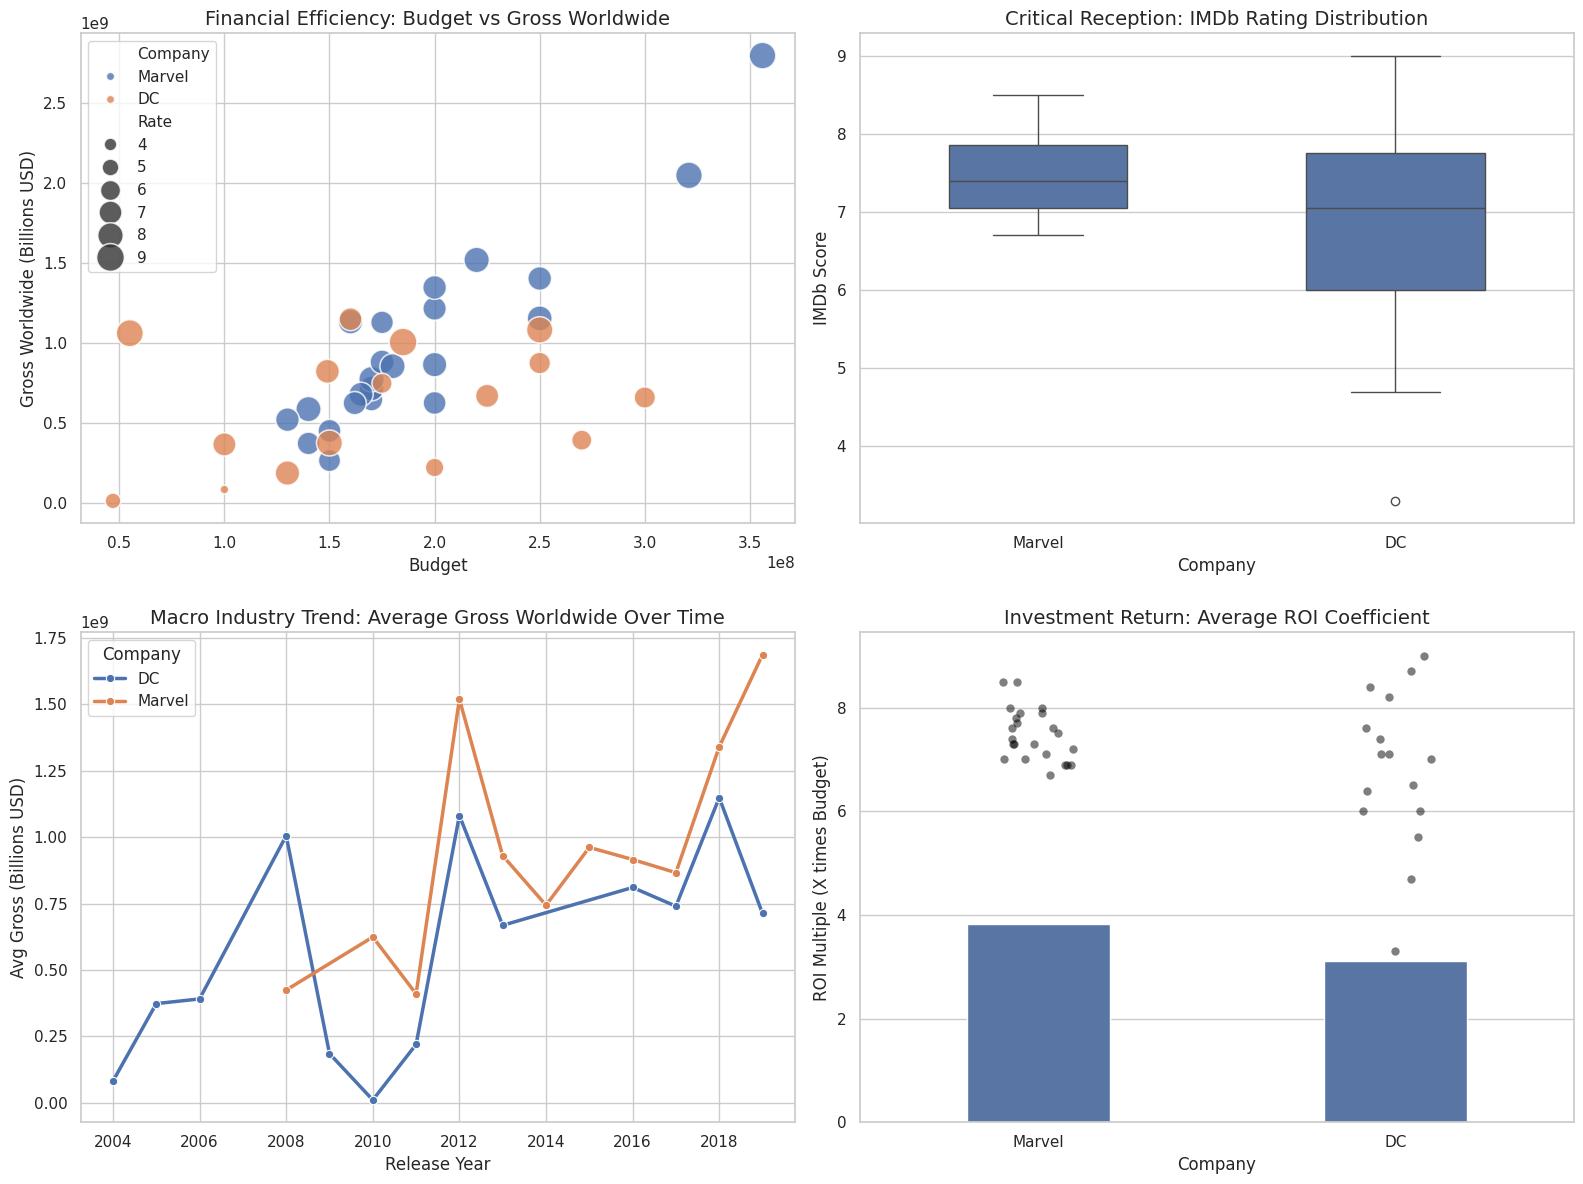

In [10]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.scatterplot(
    data=df,
    x="Budget",
    y="Gross Worldwide",
    hue="Company",
    size="Rate",
    sizes=(40, 400),
    alpha=0.8,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Financial Efficiency: Budget vs Gross Worldwide", fontsize=14)
axes[0, 0].set_ylabel("Gross Worldwide (Billions USD)")


sns.boxplot(data=df, x="Company", y="Rate", ax=axes[0, 1], width=0.5)
sns.stripplot(data=df, x="Company", y="Rate", color="black", alpha=0.5, size=6)
axes[0, 1].set_title("Critical Reception: IMDb Rating Distribution", fontsize=14)
axes[0, 1].set_ylabel("IMDb Score")


yearly_gross = df.groupby(["Release", "Company"])["Gross Worldwide"].mean().reset_index()
sns.lineplot(
    data=yearly_gross,
    x="Release",
    y="Gross Worldwide",
    hue="Company",
    marker="o",
    linewidth=2.5,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Macro Industry Trend: Average Gross Worldwide Over Time", fontsize=14)
axes[1, 0].set_xlabel("Release Year")
axes[1, 0].set_ylabel("Avg Gross (Billions USD)")


avg_roi = df.groupby("Company")["ROI"].mean().reset_index()
sns.barplot(data=avg_roi, x="Company", y="ROI", ax=axes[1, 1], width=0.4)
axes[1, 1].set_title("Investment Return: Average ROI Coefficient", fontsize=14)
axes[1, 1].set_ylabel("ROI Multiple (X times Budget)")

plt.tight_layout()
plt.show()